In [204]:

import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
import statsmodels.formula.api as smf
# my utils
from utils import desc_new_old

def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''


## data

In [2]:
path_df=r"../data_processed\listings_tactics_bio_vis-paris_london-2306_2312_2406.csv"
df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_27640\4181052062.py:2: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(266852, 125)


In [10]:
# time str
df_all['time']=df_all['time'].astype(str)
print(df_all.time.dtype)
print(df_all.time.unique())


## fillna
tactics_bio = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
]
tactics_pic=['host_picture_type']# no_person, pro_style, life_style

df_all[tactics_bio]=df_all[tactics_bio].fillna(0)
df_all["host_picture_type"]=df_all["host_picture_type"].fillna("no_person")


# dummies for host_picture_type
df=df_all.copy()
df_all['is_portrait']=df_all["host_picture_type"].apply(lambda x : 1 if x=="pro_style" else 0)
df_all['is_lifestyle']=df_all["host_picture_type"].apply(lambda x : 1 if x=="life_style" else 0)
df_all['no_person']=df_all["host_picture_type"].apply(lambda x : 1 if x=="no_person" else 0)

tactics_pic_dummies=['is_portrait','is_lifestyle','no_person']
print(df_all[tactics_pic_dummies].value_counts(dropna=False))


# time x is_paris
print(df_all[['time','in_paris']].value_counts(dropna=False))
 

object
['2306' '2312' '2406']
is_portrait  is_lifestyle  no_person
1            0             0            94648
0            0             1            91235
             1             0            80969
Name: count, dtype: int64
time  in_paris
2406  1           62738
      0           49856
2312  0           43172
2306  0           42356
2312  1           35829
2306  1           32901
Name: count, dtype: int64


In [12]:
# is_new_host
host_2306 = df_all[df_all['time'] == "2306"]['host_id'].to_list()
host_2312 = df_all[df_all['time'] == "2312"]['host_id'].to_list()


df_all['is_new_host'] = 0  # 先初始化

# 2312 vs 2306
mask_2312 = df_all['time'] == "2312"
df_all.loc[mask_2312, 'is_new_host'] = (
    ~df_all.loc[mask_2312, 'host_id'].isin(host_2306)
).astype(int)

# 2406 vs 2312
mask_2406 = df_all['time'] == "2406"
df_all.loc[mask_2406, 'is_new_host'] = (
    ~df_all.loc[mask_2406, 'host_id'].isin(host_2312)
).astype(int)

display(df_all.groupby(["time",'in_paris'])['is_new_host'].value_counts().reset_index())

,time,in_paris,is_new_host,count
0,2306,0,0,42356
1,2306,1,0,32901
2,2312,0,0,32360
3,2312,0,1,10812
4,2312,1,0,24780
5,2312,1,1,11049
6,2406,0,0,37937
7,2406,0,1,11919
8,2406,1,0,34176
9,2406,1,1,28562


In [ ]:
# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
colors = (
    list(london_colors) +
    list(paris_colors)
)

# global

In [196]:
df=df_all.copy()
agg=df.groupby(['in_paris','time'])[tactics_bio+tactics_pic_dummies].mean().reset_index()
agg_long=agg.melt(
    id_vars=['in_paris', 'time'],
    value_vars=tactics_bio+tactics_pic_dummies,
    var_name='variable',
    value_name='mean'
)
agg_long['group']=agg_long.apply(lambda row: f"{'Paris' if row['in_paris']==1 else 'Londres'} {row['time']}", axis=1)
agg_long

,in_paris,time,variable,mean,group
0,0,2306,ouverture,-0.111349,Londres 2306
1,0,2312,ouverture,-0.111726,Londres 2312
2,0,2406,ouverture,-0.113564,Londres 2406
3,1,2306,ouverture,-0.093083,Paris 2306
4,1,2312,ouverture,-0.083193,Paris 2312
5,1,2406,ouverture,-0.088205,Paris 2406
6,0,2306,authenticité,-0.181066,Londres 2306
7,0,2312,authenticité,-0.204839,Londres 2312
8,0,2406,authenticité,-0.216109,Londres 2406
9,1,2306,authenticité,-0.158274,Paris 2306


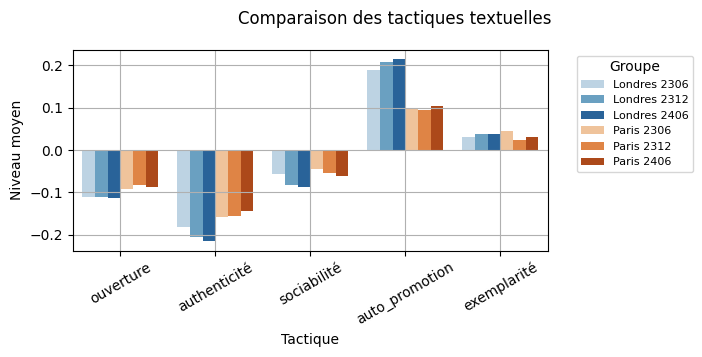

In [205]:
df_plot=agg_long.copy()
groups=df_plot['group'].unique()


# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 3  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
palette={k: v for k, v in zip (groups, colors)}


# vis
fig, ax=plt.subplots(figsize=(8,4))

sns.barplot(
    data=df_plot,   
    x="variable",
    y="mean",
    hue="group",
    palette=palette,
    order=tactics_bio,#***
    # errorbar="sd"
    ax=ax
)
ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("Niveau moyen")
ax.set_xlabel("Tactique")
ax.grid()

plt.suptitle("Comparaison des tactiques textuelles",fontsize=12)

handles, labels=ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Groupe", loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout(rect=[0,0.1, 0.9,1])

plt.show()
# 整体而言，paris更注重ouv，authen，socio，london的auto更高，exem两者相似



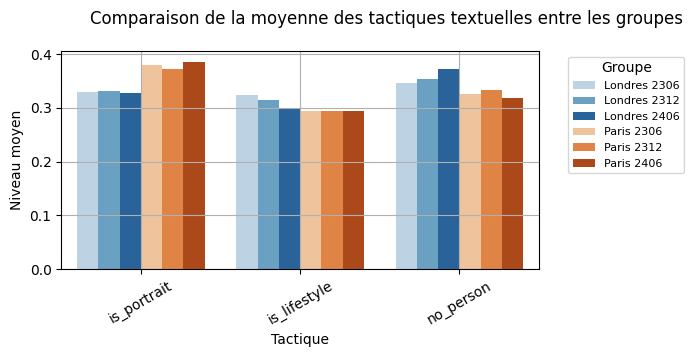

In [202]:
df_plot=agg_long.copy()
groups=df_plot['group'].unique()
fig, ax=plt.subplots(figsize=(8,4))

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 3  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
palette={k: v for k, v in zip (groups, colors)}


sns.barplot(
    data=df_plot,   # ⚠️ 用 df_long（不是 df_stats）
    x="variable",
    y="mean",
    hue="group",
    palette=palette,
    order=tactics_pic_dummies,
    # errorbar="sd"
    ax=ax
)
ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("Niveau moyen")
ax.set_xlabel("Tactique")
ax.grid()

plt.suptitle("Comparaison des tactiques visuelles",fontsize=12)
handles, labels=ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Groupe", loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout(rect=[0,0.1, 0.9,1])
plt.show()

#三种类型非常均匀，随时间变化稳定
# 巴黎的portrait相较于london更高高，lifestyle近似，no_person更低

In [212]:
var='authenticité'
df=df_all.copy()

formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "C(time) + in_paris * C(time)"
    )
model_tactic=smf.ols(formula, data=df).fit()
print(model_tactic.summary())


                            OLS Regression Results                            
Dep. Variable:           authenticité   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     2007.
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:48:24   Log-Likelihood:            -2.6399e+05
No. Observations:              266852   AIC:                         5.280e+05
Df Residuals:                  266824   BIC:                         5.283e+05
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [297]:
## global: yerrobar, textuelles + visuelles !

specs=[
    # constants: time=2312-2406, in_paris: paris-london, 
    # is_new_host, terms 
    # (1, """
    #     in_paris:C(time)[T.2406]:is_new_host
    #     - in_paris:C(time)[T.2312]:is_new_host
    #     - C(time)[T.2406]:is_new_host
    #     + C(time)[T.2312]:is_new_host
    #     """), 
    # 在新老房东对比中，2312作为了基准组，
    
    """    
    in_paris:C(time)[T.2406]
    -in_paris:C(time)[T.2312]
    - C(time)[T.2406]
    + C(time)[T.2312]
    """
]

df=df_all.copy()
results=[]
for var in tactics_bio+tactics_pic_dummies:
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                "number_of_reviews_ltm + "
                "C(host_is_superhost) +"
                "years_since_host + professional_host + "
                "host_response_rate +  C(host_response_time)+"
                "has_text + lang_en + lang_fr + text_length+"
                "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                "C(time) + in_paris * C(time)"
        )
    model_tactic=smf.ols(formula, data=df).fit()

    for i, term in enumerate(specs):
        test = model_tactic.t_test(term)
        sig=p_to_sig(test.pvalue)
        res= pd.DataFrame({
            'variable':var,
            "coef": test.effect[0],
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":sig,
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var}{sig}"
        })
        results.append(res)

results_ddd_all=pd.concat(results, axis=0)
display(results_ddd_all)
# 以前的那个图是在每一个时间点上的差，现在的这个还减去了时间2406-2312的差异!

,variable,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,-0.003929,0.009298,6.726216e-01,,-0.022153,0.014295,ouverture
0,authenticité,0.023845,0.009631,1.329529e-02,*,0.004968,0.042723,authenticité*
0,sociabilité,0.022006,0.009954,2.704422e-02,*,0.002498,0.041515,sociabilité*
0,auto_promotion,0.025596,0.009074,4.792441e-03,**,0.007811,0.043382,auto_promotion**
0,exemplarité,0.033232,0.009641,5.670961e-04,***,0.014336,0.052129,exemplarité***
0,is_portrait,0.017005,0.006841,1.292948e-02,*,0.003597,0.030414,is_portrait*
0,is_lifestyle,0.027812,0.006626,2.703338e-05,***,0.014824,0.040799,is_lifestyle***
0,no_person,-0.044817,0.006206,5.158131e-13,***,-0.056981,-0.032653,no_person***


In [ ]:
results_ddd_all

,variable,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,-0.003929,0.009298,6.726216e-01,,-0.022153,0.014295,ouverture
0,authenticité,0.023845,0.009631,1.329529e-02,*,0.004968,0.042723,authenticité*
0,sociabilité,0.022006,0.009954,2.704422e-02,*,0.002498,0.041515,sociabilité*
0,auto_promotion,0.025596,0.009074,4.792441e-03,**,0.007811,0.043382,auto_promotion**
0,exemplarité,0.033232,0.009641,5.670961e-04,***,0.014336,0.052129,exemplarité***
0,is_portrait,0.017005,0.006841,1.292948e-02,*,0.003597,0.030414,is_portrait*
0,is_lifestyle,0.027812,0.006626,2.703338e-05,***,0.014824,0.040799,is_lifestyle***
0,no_person,-0.044817,0.006206,5.158131e-13,***,-0.056981,-0.032653,no_person***


,variable,coef,se,pval,sig,ci_low,ci_high,label
0,exemplarité,0.033232,0.009641,0.000567,***,0.014336,0.052129,exemplarité***
1,auto_promotion,0.025596,0.009074,0.004792,**,0.007811,0.043382,auto_promotion**
2,sociabilité,0.022006,0.009954,0.027044,*,0.002498,0.041515,sociabilité*
3,authenticité,0.023845,0.009631,0.013295,*,0.004968,0.042723,authenticité*
4,ouverture,-0.003929,0.009298,0.672622,,-0.022153,0.014295,ouverture


,variable,coef,se,pval,sig,ci_low,ci_high,label
0,no_person,-0.044817,0.006206,5.158131e-13,***,-0.056981,-0.032653,no_person***
1,is_lifestyle,0.027812,0.006626,2.703338e-05,***,0.014824,0.040799,is_lifestyle***
2,is_portrait,0.017005,0.006841,1.292948e-02,*,0.003597,0.030414,is_portrait*


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27640\798955294.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


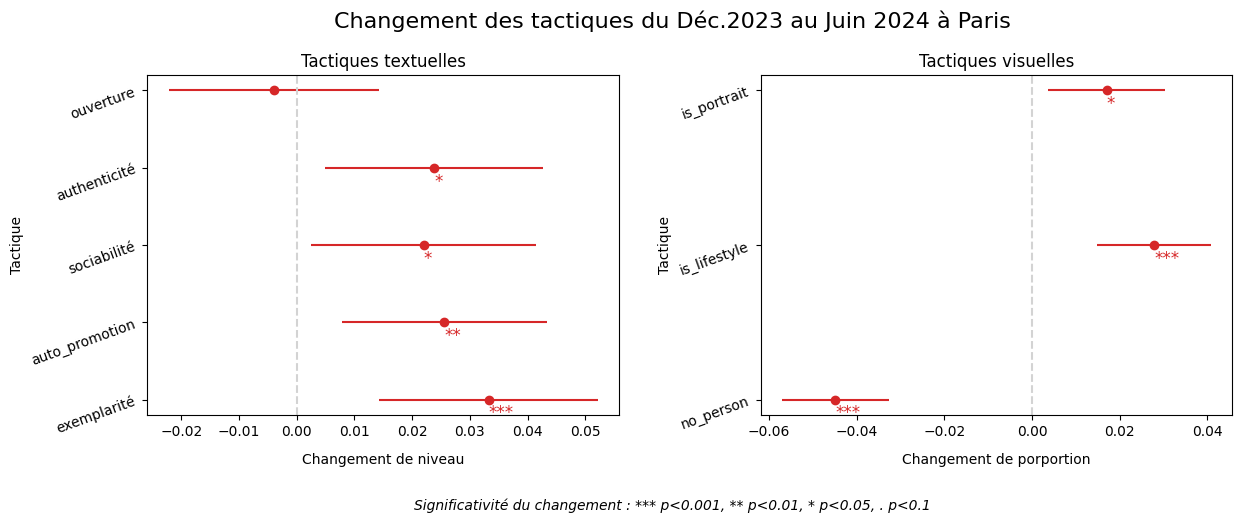

In [298]:
# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.5, 0.8, n))

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])#**
axes.extend([ax1, ax2])


#
df_plot=results_ddd_all.copy()
color_change="tab:red"


for i, tactics in enumerate([tactics_bio, tactics_pic_dummies]):
    sub=df_plot[df_plot['variable'].isin(tactics)].copy()

    order = tactics[::-1]
    sub = sub.set_index("variable").loc[order].reset_index()    
    ax=axes[i]
    
    # #规定顺序：
    # sub['variable']=pd.Categorical(
    #     sub['variable'],
    #     categories=tactics[::-1],
    #     ordered=True
    # )    
    display(sub)# 5/3

    ax.errorbar(
        x=sub["coef"],
        y=sub["variable"],
        xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
        fmt='o', 
        # order = tactics[::-1],
        color=color_change
    )
    # ---sig---
    for _, row in sub.iterrows():
        ax.annotate(
            row["sig"],
            xy=(row["coef"], row["variable"]),
            xytext=(0, -10), 
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=12,
            color=color_change
    )    
            
    ax.axvline(0, linestyle='--', color="lightgray", label="Changement de Londres")    
    ax.set_xlabel(f"{'Changement de niveau' if i==0 else 'Changement de porportion'}", labelpad=10)
    ax.set_ylabel('Tactique')
    ax.tick_params(axis='y', rotation=20)
    ax.set_title(f"{'Tactiques textuelles' if i==0 else 'Tactiques visuelles'}")

# ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)


# ## ---legend 2facets----
fig.suptitle(
    "Changement des tactiques du Déc.2023 au Juin 2024 à Paris",
    fontsize=16,
    y=1.01
)
plt.figtext(
    0.5, 0.01,
    "Significativité du changement : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

# ==paris从2306到2406的变化减去自然变化（london）==jo带来的额外变化
# ?? 考虑不平行趋势了吗？
# 提升所有text，和有人物的头像


In [ ]:
## real+cf effet 
def get_cf_data(df, model, var):
    """
    不改变时间，不改变地点，仅减去jo（交互项之差）
    """    
    df["y_hat"] = model.predict(df)
    term = ('''
        in_paris:C(time)[T.2406]
        - in_paris:C(time)[T.2312]
        - C(time)[T.2406]
        + C(time)[T.2312]
    '''
    )#jo shock，没有2406-2312则是paris shock
    #将2312作为了变化的基准，所以不用考虑2306-2312的不平行
    
    test = model_tactic.t_test(term)
    adjustment=test.effect[0]
    pval=test.pvalue
    sig=p_to_sig(pval)
               
    print(f'ddd of {var}: {adjustment} {sig}')
    df["y_cf"] = df["y_hat"]

    df.loc[
        (df["in_paris"]==1) & (df["time"]=="2406"),
        "y_cf"
    ] -= adjustment#==去掉2406交互项，再加一次2312交互项
    
    agg=df.groupby(['in_paris','time'])[['y_hat','y_cf']].mean().reset_index()
    agg['variable']=var
    
    # +pval +sig
    agg["pval"] = np.nan 
    agg["sig"] = np.nan 
    
    agg.loc[
        (agg['in_paris']==1)&(agg['time']=="2406"),
        'pval'
            ]=pval
    agg.loc[
        (agg['in_paris']==1)&(agg['time']=="2406"),
        'sig'
            ]=sig
    
    return agg 


aggs=[]
for var in tactics_bio+tactics_pic_dummies:
    print(var)
    # var='authenticité'
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                    "number_of_reviews_ltm + "
                    "C(host_is_superhost) +"
                    "years_since_host + professional_host + "
                    "host_response_rate +  C(host_response_time)+"
                    "has_text + lang_en + lang_fr + text_length+"
                    "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                    "C(time) + in_paris * C(time)"
            )
    model_tactic=smf.ols(formula, data=df).fit()
    agg=get_cf_data(df=df_all, model=model_tactic, var=var)
    aggs.append(agg)
    # break
cf_data=pd.concat(aggs,axis=0)
cf_data

ouverture
ddd of ouverture: -0.003928918613157289 
authenticité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27640\2329313411.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


ddd of authenticité: 0.02384538137177546 *
sociabilité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27640\2329313411.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '*' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


ddd of sociabilité: 0.02200635617159638 *
auto_promotion


...

ddd of is_lifestyle: 0.027811608493118645 ***
no_person


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27640\2329313411.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '***' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


ddd of no_person: -0.04481708926515214 ***


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27640\2329313411.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '***' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


,in_paris,time,y_hat,y_cf,variable,pval,sig
0,0,2306,-0.111349,-0.111349,ouverture,NaN,NaN
1,0,2312,-0.111726,-0.111726,ouverture,NaN,NaN
2,0,2406,-0.113564,-0.113564,ouverture,NaN,NaN
3,1,2306,-0.093083,-0.093083,ouverture,NaN,NaN
4,1,2312,-0.083193,-0.083193,ouverture,NaN,NaN
5,1,2406,-0.088205,-0.084276,ouverture,6.726216e-01,
0,0,2306,-0.181066,-0.181066,authenticité,NaN,NaN
1,0,2312,-0.204839,-0.204839,authenticité,NaN,NaN
2,0,2406,-0.216109,-0.216109,authenticité,NaN,NaN
3,1,2306,-0.158274,-0.158274,authenticité,NaN,NaN


['ouverture' 'authenticité' 'sociabilité' 'auto_promotion' 'exemplarité']


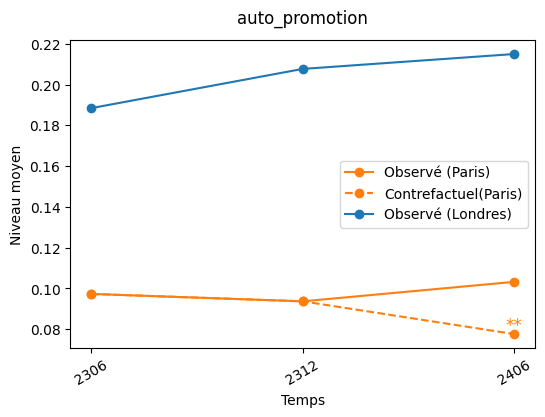

In [273]:
def plot_one_cf(cf_data, axes=None, i=0,  var="authenticité", title=None, ylabel=None):
    if not axes:
        fig, ax=plt.subplots(figsize=(6,4))
    else :
        ax=axes[i]

    sub=cf_data[cf_data['variable']==var]
    # display(sub)
    
    x=list(range(len(sub['time'].unique())))
    # print("axis x :", x)
    
    ## plt
    paris = sub[sub["in_paris"] == 1]    
    # ---paris obs---
    ax.plot(
        x,
        # paris["time"],#.map(time_map),        
        paris["y_hat"],
        marker="o",
        label="Observé (Paris)",
        color='tab:orange'
    )    
    
    # ---paris cf---
    ax.plot(
        x,
        # paris["time"],#.map(time_map),
        paris["y_cf"],
        marker="o",
        linestyle="--",
        label="Contrefactuel(Paris)",
        color='tab:orange'
    )
    # + sig
    ddd_sig=sub[(sub['in_paris']==1)&(sub['time']=="2406")]['sig'].iloc[0]
    # ddd_sig=ddd_data[ddd_data['variable']==var]['sig'].iiloc[0]
    xi,yi, sig=2, paris[paris["time"]=="2406"]['y_cf'].iloc[0],ddd_sig
    ax.text(xi, yi + 0.002, sig, ha='center', 
        color='tab:orange', fontsize=12)
    
    
    # ---london obs---
    control = sub[sub["in_paris"] == 0]
    ax.plot(
        control["time"],#.map(time_map),
        control["y_hat"],
        marker="o",
        # alpha=0.4,
        label="Observé (Londres)",
        color='tab:blue'
    )
    
    ax.set_xticks(x)
    ax.set_xticklabels(sub['time'].unique())
    ax.tick_params(axis='x', rotation=30)
    
    ylabel="Niveau moyen" if ylabel is None else ylabel
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Temps")

    title=var if title==None else title
    ax.set_title(f"{title}", pad=12)
    if not axes:
        ax.legend(fontsize=10)
        
    return 


df_plot=cf_data[cf_data['variable'].isin(tactics_bio)]
print(df_plot.variable.unique())
var='auto_promotion'

plot_one_cf(cf_data=df_plot, axes=None, i=0,  var=var, title=None, ylabel=None)
    
    
# plot_one_cf(agg_data, axes=None, i=0,  var=var, ddd_data=ddd_data, title=None, ylabel=None)


tactics:  ['ouverture' 'authenticité' 'sociabilité' 'auto_promotion' 'exemplarité']


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27640\3209924823.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


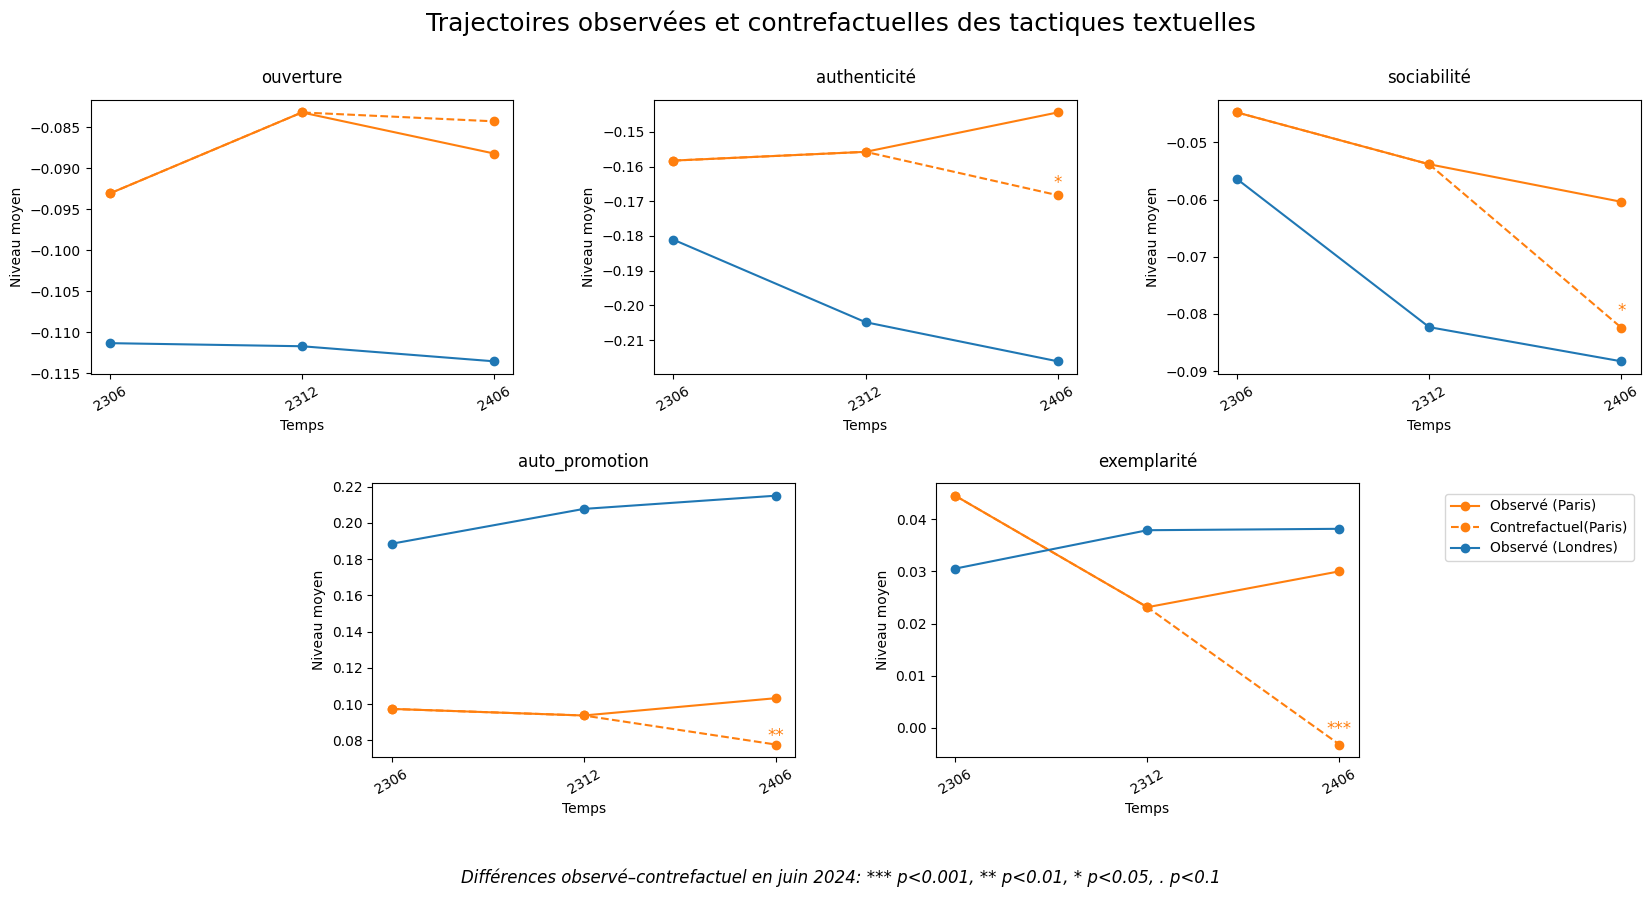

In [ ]:
# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


## plot:

df_plot=cf_data[cf_data['variable'].isin(tactics_bio)]
print('tactics: ',df_plot.variable.unique())
for i, var in enumerate(tactics_bio):
    plot_one_cf(cf_data=df_plot, axes=axes, i=i,  var=var, title=None, ylabel=None)
    

# layout:
fig.suptitle(
        "Trajectoires observées et contrefactuelles des tactiques textuelles",
        fontsize=18,
        y=0.98
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité des différences observé–contrefactuel en juin 2024: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()

# authen，auto，exem上升，ouv不显著变化，socio下降
# 但是jo都有提升效果！


tactics:  ['is_portrait' 'is_lifestyle' 'no_person']


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27640\35261457.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8,1])


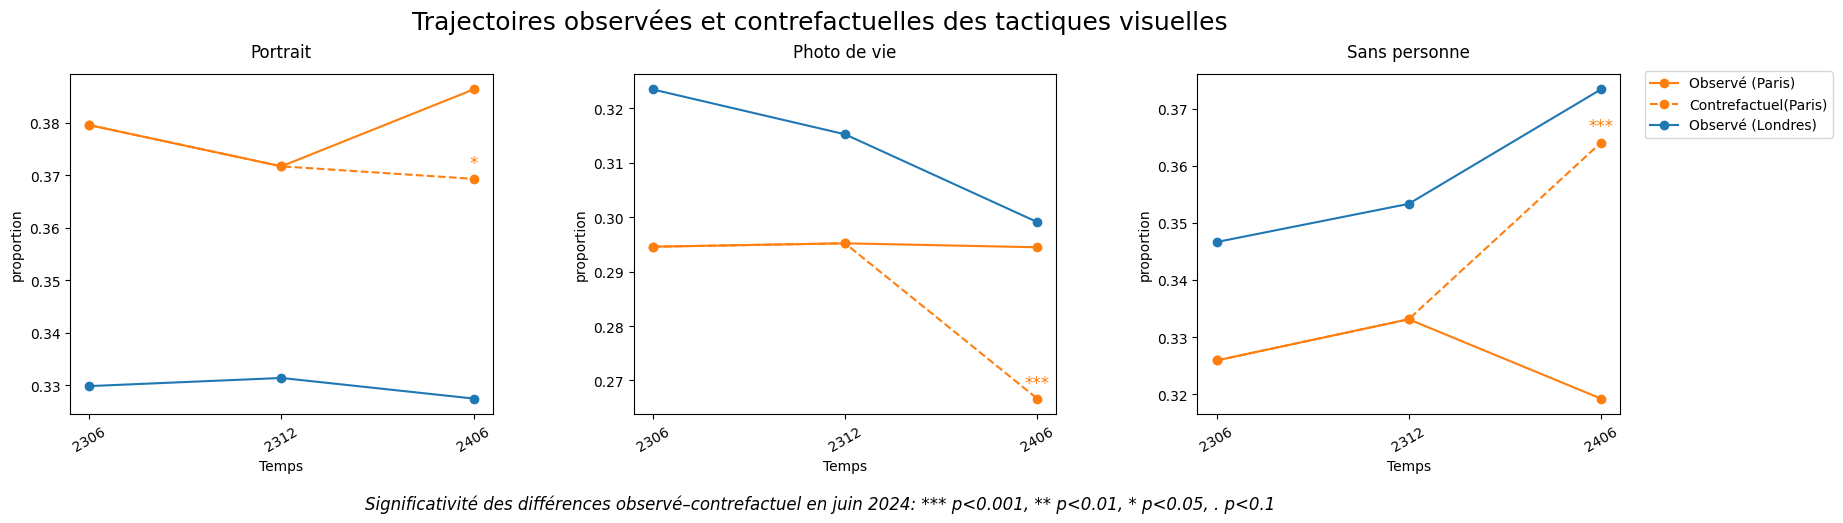

In [ ]:
# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,5))# sharey=True
gs = gridspec.GridSpec(1, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# # 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
# ax4 = fig.add_subplot(gs[1, 1:3])
# ax5 = fig.add_subplot(gs[1, 3:5])
# axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


## plot:
df_plot=cf_data[cf_data['variable'].isin(tactics_pic_dummies)]#**
print('tactics: ',df_plot.variable.unique())

title_map={
    'is_portrait':'Portrait',
    'is_lifestyle':'Photo de vie',
    "no_person":"Sans personne"
}
for i, var in enumerate(tactics_pic_dummies):#**
    plot_one_cf(cf_data=df_plot, axes=axes, i=i,  var=var, title=title_map.get(var,""), ylabel='proportion')
      
# layout:
fig.suptitle(
        "Trajectoires observées et contrefactuelles des tactiques visuelles",
        fontsize=18,
        y=1.01
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.01,0.9) # legend (x, y)，x>1则在图外, y=0在底线
)
plt.figtext(
    0.5, 0.01,
    "Significativité des différences observé–contrefactuel en juin 2024: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 0.8,1])
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()


# 总体上por上升，vie不变，sans下降！

## new old

In [ ]:
## 2406 london + paris new vs old
import matplotlib.pyplot as plt
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_new_old

# ---plot data---    
ordered_tactics=tactics_bio + tactics_pic_dummies
df=df_all.copy()
df_plot=ttest_new_old(df, times=["2312","2406"], in_paris=[0,1], vars=ordered_tactics)
df_plot

(266852, 129) => (191595, 129)


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,0,ouverture,10.772661,5.443153e-27,***,1,-0.054907,ouverture ***
0,2312,0,ouverture,10.772661,5.443153e-27,***,0,-0.130710,ouverture ***
0,2312,0,authenticité,24.416914,5.180670e-130,***,1,-0.068509,authenticité ***
0,2312,0,authenticité,24.416914,5.180670e-130,***,0,-0.250389,authenticité ***
0,2312,0,sociabilité,4.340929,1.425113e-05,***,1,-0.058570,sociabilité ***
0,2312,0,sociabilité,4.340929,1.425113e-05,***,0,-0.090225,sociabilité ***
0,2312,0,auto_promotion,-29.668233,7.176860e-190,***,1,0.038115,auto_promotion ***
0,2312,0,auto_promotion,-29.668233,7.176860e-190,***,0,0.264328,auto_promotion ***
0,2312,0,exemplarité,-7.554386,4.366086e-14,***,1,-0.001066,exemplarité ***
0,2312,0,exemplarité,-7.554386,4.366086e-14,***,0,0.050942,exemplarité ***


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2406,1,ouverture,20.624160,3.426978e-94,***,1,-0.034036,ouverture ***
0,2406,1,ouverture,20.624160,3.426978e-94,***,0,-0.133475,ouverture ***
0,2406,1,authenticité,41.635065,0.000000e+00,***,1,-0.029554,authenticité ***
0,2406,1,authenticité,41.635065,0.000000e+00,***,0,-0.240384,authenticité ***
0,2406,1,sociabilité,16.005879,1.513599e-57,***,1,-0.017548,sociabilité ***
0,2406,1,sociabilité,16.005879,1.513599e-57,***,0,-0.096182,sociabilité ***
0,2406,1,auto_promotion,-36.799807,2.555253e-293,***,1,0.003604,auto_promotion ***
0,2406,1,auto_promotion,-36.799807,2.555253e-293,***,0,0.186465,auto_promotion ***
0,2406,1,exemplarité,0.662822,5.074473e-01,,1,0.031944,exemplarité
0,2406,1,exemplarité,0.662822,5.074473e-01,,0,0.028441,exemplarité


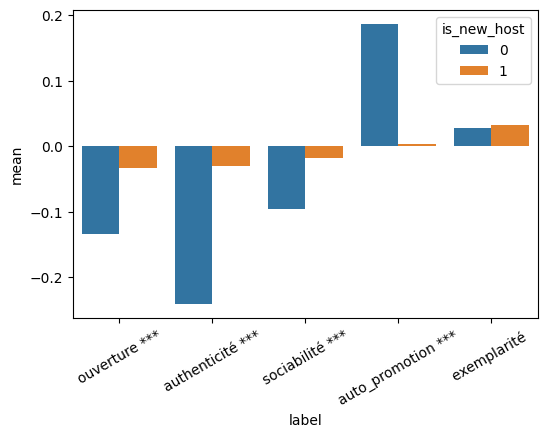

In [57]:
# subplots : time*city, hue:new/old, x=variable
p=1
t="2406"
sub=df_plot[(df_plot['in_paris']==p)&(df_plot['time']==t)]
display(sub)
fig, ax=plt.subplots(figsize=(6,4))

sns.barplot(
        data=sub,   
        # x='variable',
        x="label",
        y="mean",
        hue="is_new_host",
        # palette=palette,
        # order=ordered_tactics,
        # ax=ax,
    )    
ax.tick_params(axis="x", rotation=30)


in_paris=0, time=2312
10
in_paris=0, time=2406
10
in_paris=1, time=2312
10
in_paris=1, time=2406
10


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27640\4274951945.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


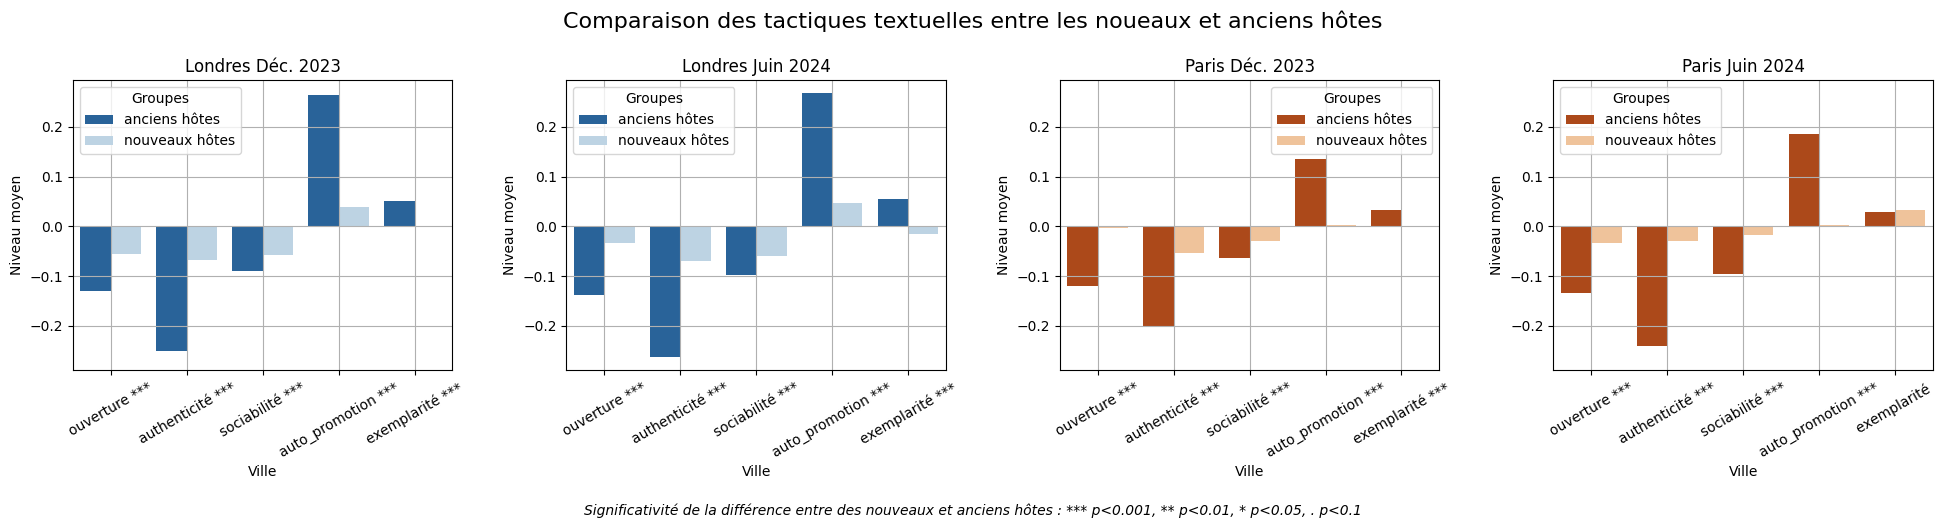

In [60]:
## 2406 london + paris NEW vs OLD

import matplotlib.pyplot as plt
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_new_old

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
colors = (
    list(london_colors) +
    list(paris_colors)
)

## ---layout 4facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(24, 5)) 
gs = gridspec.GridSpec(1, 4, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharey=ax1)#**
ax3 = fig.add_subplot(gs[0, 2:3], sharey=ax1)#**
ax4 = fig.add_subplot(gs[0, 3:4], sharey=ax1)#**
axes.extend([ax1, ax2, ax3, ax4])

# ---plot---
subplot_col1='in_paris'
subplot_col2='time'
i=0

for p in df_plot[subplot_col1].unique():
    for t in df_plot[subplot_col2].unique():
        print(f"{subplot_col1}={p}, {subplot_col2}={t}")
        ax=axes[i]
        
        # ---sub data---
        sub=df_plot[(df_plot[subplot_col1]==p)&(df_plot[subplot_col2]==t)]
        print(len(sub))#==10==5 tactics *2 new/old
        
        if p==1:
            palette=dict(zip(sub['is_new_host'], paris_colors))
        else :
            palette=dict(zip(sub['is_new_host'], london_colors))
    
        sns.barplot(
            data=sub,   
            x='label',
            y="mean",
            hue="is_new_host",
            palette=palette,
            # order=ordered_tactics,
            ax=ax,
        )    
    
        # label_map = (
        #     sub[['variable', 'sig']]
        #     .drop_duplicates()
        #     .set_index('variable')['sig']
        # )
        # ax.set_xticklabels([
        #     f"{var} {label_map.get(var, '')}".strip()
        #     for var in ordered_tactics
        # ])

        ax.set_xlabel("Ville")
        ax.set_ylabel("Niveau moyen")
        ax.tick_params(axis="x",rotation=30)

        ax.set_title(f"{'Paris' if p==1 else 'Londres'} {'Déc. 2023' if t=='2312' else 'Juin 2024'}")
        
        handles, labels = ax.get_legend_handles_labels()
        new_labels = ["anciens hôtes", "nouveaux hôtes"]
        ax.legend(handles, new_labels, title="Groupes")
        
        ax.grid()
        i+=1
        

## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques textuelles entre les noueaux et anciens hôtes",
        fontsize=16,
        y=1.02
    )

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence entre des nouveaux et anciens hôtes : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.3)#控制子图到底的距离，给text留出空间
plt.show()


# 横截面差异（cross-sectional difference）
# 在任何一组中，新老房东的表现出不同的策略倾向：新房东ouv, authen, socio水平更高，但在auto, exem水平更低
# ttest属于描述，不解释因果！


# 从2312到2406,这个倾向是否是稳定的？是否发生变化?

(266852, 129) => (39611, 129)
is_new_host  time  in_paris
1            2406  1           28562
             2312  1           11049
Name: count, dtype: int64


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label,change
0,2312,1,ouverture,5.533963,3.166305e-08,***,1,-0.002521,ouverture ***,-
0,2406,1,ouverture,5.533963,3.166305e-08,***,1,-0.034036,ouverture ***,-
0,2312,1,authenticité,-4.029937,5.599858e-05,***,1,-0.054085,authenticité ***,+
0,2406,1,authenticité,-4.029937,5.599858e-05,***,1,-0.029554,authenticité ***,+
0,2312,1,sociabilité,-2.129152,3.325350e-02,*,1,-0.030222,sociabilité *,+
0,2406,1,sociabilité,-2.129152,3.325350e-02,*,1,-0.017548,sociabilité *,+
0,2312,1,auto_promotion,-0.241920,8.088449e-01,,1,0.002145,auto_promotion,+
0,2406,1,auto_promotion,-0.241920,8.088449e-01,,1,0.003604,auto_promotion,+
0,2312,1,exemplarité,-4.898418,9.723848e-07,***,1,0.001056,exemplarité ***,+
0,2406,1,exemplarité,-4.898418,9.723848e-07,***,1,0.031944,exemplarité ***,+


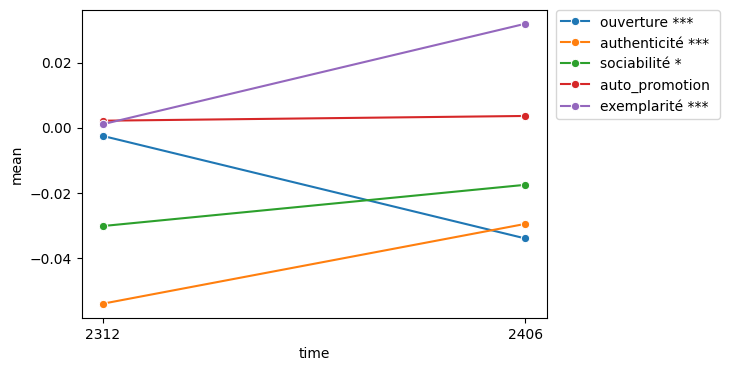

In [72]:

importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_by_time

df_plot_time=ttest_by_time(df=df_all, 
                           times=["2312","2406"], in_paris=[1], is_new_host=[1], 
                           vars=tactics_bio)
df_plot_time


p=1
new=1
sub=df_plot_time[(df_plot_time['in_paris']==p)&(df_plot_time['is_new_host']==new)]
display(sub)
fig, ax=plt.subplots(figsize=(6,4))
sns.lineplot(
    data=sub,
    x='time',
    y="mean",
    hue="label",
    marker="o",
    ax=ax
)
# ax.legend()
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)


In [67]:
df_plot_time=ttest_by_time(df=df_all, 
                           times=["2312","2406"], in_paris=[0, 1], is_new_host=[0, 1], 
                           vars=tactics_bio)
df_plot_time

(266852, 129) => (191595, 129)
is_new_host  time  in_paris
0            2406  0           37937
                   1           34176
             2312  0           32360
1            2406  1           28562
0            2312  1           24780
1            2406  0           11919
             2312  1           11049
                   0           10812
Name: count, dtype: int64


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label,change
0,2312,0,ouverture,-2.769081,5.626104e-03,**,1,-0.054907,ouverture **,+
0,2406,0,ouverture,-2.769081,5.626104e-03,**,1,-0.032854,ouverture **,+
0,2312,0,authenticité,0.048290,9.614855e-01,,1,-0.068509,authenticité,-
0,2406,0,authenticité,0.048290,9.614855e-01,,1,-0.068915,authenticité,-
0,2312,0,sociabilité,0.249636,8.028712e-01,,1,-0.058570,sociabilité,-
0,2406,0,sociabilité,0.249636,8.028712e-01,,1,-0.060629,sociabilité,-
0,2312,0,auto_promotion,-1.081306,2.795725e-01,,1,0.038115,auto_promotion,+
0,2406,0,auto_promotion,-1.081306,2.795725e-01,,1,0.047285,auto_promotion,+
0,2312,0,exemplarité,1.834206,6.663659e-02,.,1,-0.001066,exemplarité .,-
0,2406,0,exemplarité,1.834206,6.663659e-02,.,1,-0.015097,exemplarité .,-


in_paris=0, is_new_host=1
10
in_paris=0, is_new_host=0
10
in_paris=1, is_new_host=1
10
in_paris=1, is_new_host=0
10


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27640\25336207.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]


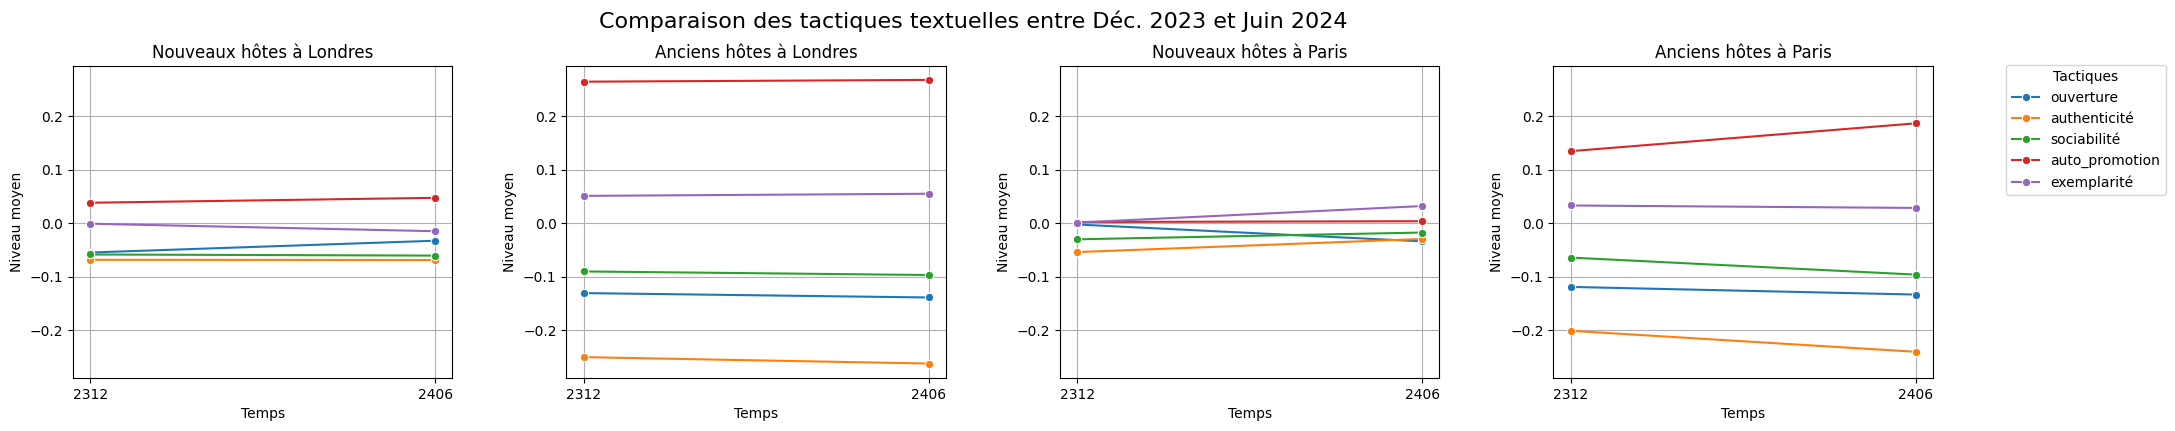

In [83]:
## london + paris new + old 2312 vs 2406
import matplotlib.pyplot as plt
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_new_old

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
colors = (
    list(london_colors) +
    list(paris_colors)
)

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(24, 4)) 
gs = gridspec.GridSpec(1, 4, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharey=ax1)#**
ax3 = fig.add_subplot(gs[0, 2:3], sharey=ax1)#**
ax4 = fig.add_subplot(gs[0, 3:4], sharey=ax1)#**
axes.extend([ax1, ax2, ax3, ax4])

# ---plot---
subplot_col1='in_paris'
subplot_col2='is_new_host'
i=0
for p in df_plot[subplot_col1].unique():#***
    for new in df_plot[subplot_col2].unique():#***
        print(f"{subplot_col1}={p}, {subplot_col2}={new}")#***
        ax=axes[i]
        
        # ---sub data---
        sub=df_plot[(df_plot[subplot_col1]==p)&(df_plot[subplot_col2]==new)]#***
        # display(sub)
        print(len(sub))#=5 tactics*2 times=10
        
        sns.lineplot(
            data=sub,
            x='time',#***hue
            y="mean",
            hue="variable",
            marker="o",
            ax=ax
        )

        ax.set_xlabel("Temps")
        ax.set_ylabel("Niveau moyen")
        # ax.tick_params(axis="x",rotation=30)
        ax.set_title(f"{'Nouveaux hôtes' if new==1 else 'Anciens hôtes'} à {'Paris' if p==1 else 'Londres'}")
        if ax.legend():
            ax.get_legend().remove()
            
        # ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
        ax.grid()
        i+=1
        

## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques textuelles entre Déc. 2023 et Juin 2024",
        fontsize=16,
        y=1.02
    )


# plt.figtext(
#     0.5, 0.01,
#     "Significativité de la différence entre des nouveaux et anciens hôtes : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
#     ha="center",
#     fontsize=10,
#     style="italic",   
# )

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Tactiques", loc="upper right", bbox_to_anchor=(1, 0.9))
plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间

plt.show()


#新老房东使用策略是否发生随时间发生显著变化？
# 先看平均水平：几乎都是是平行的

## ttest显著但是还需要检查效应量！极小的差异也可能显著cohensd

## 如果有jo冲击，paris新房东变化-london新房东变化显著， paris老房东变化-london老房东变化显著，
# 但新老房东显著的策略不同？

## modeling

In [ ]:
## 如果有jo冲击，paris新房东变化-london新房东变化显著， paris老房东变化-london老房东变化显著，
# paris新房东变化==(in_paris:C(time)[T.2406]:is_new_host-in_paris:C(time)[T.2312]:is_new_host)
# london新房东变化==(C(time)[T.2406]:is_new_host-C(time)[T.2312]:is_new_host)

# jo_on_new=paris新房东变化-london新房东变化

In [84]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
y="authenticité"
formula= (f"{y} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "C(time) + in_paris * C(time)*is_new_host"
)

model_new=smf.ols(formula, data=df).fit()
print(model_new.summary())

                            OLS Regression Results                            
Dep. Variable:           authenticité   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     1770.
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:46:33   Log-Likelihood:            -2.6370e+05
No. Observations:              266852   AIC:                         5.275e+05
Df Residuals:                  266820   BIC:                         5.278e+05
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [299]:
def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''


specs=[
    # constants: time=2312-2406, in_paris: paris-london, 
    # is_new_host, terms 
    (1, """
        in_paris:C(time)[T.2406]:is_new_host
        - in_paris:C(time)[T.2312]:is_new_host
        - C(time)[T.2406]:is_new_host
        + C(time)[T.2312]:is_new_host
        """), 
    (0, """
        in_paris:C(time)[T.2406]
        - in_paris:C(time)[T.2312]
        - C(time)[T.2406]
        + C(time)[T.2312]
        """) 
]

df=df_all.copy()
results=[]

for var in tactics_bio+tactics_pic_dummies:
    print(var)
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "C(time) + in_paris * C(time)*is_new_host"
    )
    model_new=smf.ols(formula, data=df).fit()

    for i, (new, term) in enumerate(specs):
        test = model_new.t_test(term)
        sig=p_to_sig(test.pvalue)
        res= pd.DataFrame({
            'variable':var,
            "is_new_host":new,
            "coef": test.effect[0],
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":sig,
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var}{sig}"
        })
        results.append(res)
    # break

results_ddd_new=pd.concat(results, axis=0)
display(results_ddd_new)  

ouverture
authenticité
sociabilité
auto_promotion
exemplarité
is_portrait
is_lifestyle
no_person


,variable,is_new_host,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,1,-0.086817,0.021123,0.000040,***,-0.128218,-0.045417,ouverture***
0,ouverture,0,0.013355,0.010890,0.220079,,-0.007990,0.034699,ouverture
0,authenticité,1,-0.001533,0.021869,0.944105,,-0.044396,0.041329,authenticité
0,authenticité,0,0.007680,0.011275,0.495761,,-0.014418,0.029778,authenticité
0,sociabilité,1,0.047872,0.022615,0.034277,*,0.003547,0.092198,sociabilité*
0,sociabilité,0,-0.003463,0.011660,0.766429,,-0.026316,0.019389,sociabilité
0,auto_promotion,1,0.013010,0.020614,0.527946,,-0.027392,0.053412,auto_promotion
0,auto_promotion,0,0.027796,0.010627,0.008911,**,0.006966,0.048625,auto_promotion**
0,exemplarité,1,0.102813,0.021905,0.000003,***,0.059880,0.145747,exemplarité***
0,exemplarité,0,-0.003397,0.011293,0.763598,,-0.025531,0.018738,exemplarité


In [114]:
new=1
sub=results_ddd[results_ddd['is_new_host']==new]
sub

,variable,is_new_host,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,1,-0.086817,0.021123,0.000040,***,-0.128218,-0.045417,ouverture***
0,authenticité,1,-0.001533,0.021869,0.944105,,-0.044396,0.041329,authenticité
0,sociabilité,1,0.047872,0.022615,0.034277,*,0.003547,0.092198,sociabilité*
0,auto_promotion,1,0.013010,0.020614,0.527946,,-0.027392,0.053412,auto_promotion
0,exemplarité,1,0.102813,0.021905,0.000003,***,0.059880,0.145747,exemplarité***


is_new_host=1


,variable,is_new_host,coef,se,pval,sig,ci_low,ci_high,label
0,exemplarité,1,0.102813,0.021905,0.000003,***,0.059880,0.145747,exemplarité***
1,auto_promotion,1,0.013010,0.020614,0.527946,,-0.027392,0.053412,auto_promotion
2,sociabilité,1,0.047872,0.022615,0.034277,*,0.003547,0.092198,sociabilité*
3,authenticité,1,-0.001533,0.021869,0.944105,,-0.044396,0.041329,authenticité
4,ouverture,1,-0.086817,0.021123,0.000040,***,-0.128218,-0.045417,ouverture***


is_new_host=0


,variable,is_new_host,coef,se,pval,sig,ci_low,ci_high,label
0,exemplarité,0,-0.003397,0.011293,0.763598,,-0.025531,0.018738,exemplarité
1,auto_promotion,0,0.027796,0.010627,0.008911,**,0.006966,0.048625,auto_promotion**
2,sociabilité,0,-0.003463,0.011660,0.766429,,-0.026316,0.019389,sociabilité
3,authenticité,0,0.007680,0.011275,0.495761,,-0.014418,0.029778,authenticité
4,ouverture,0,0.013355,0.010890,0.220079,,-0.007990,0.034699,ouverture


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27640\3671654280.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


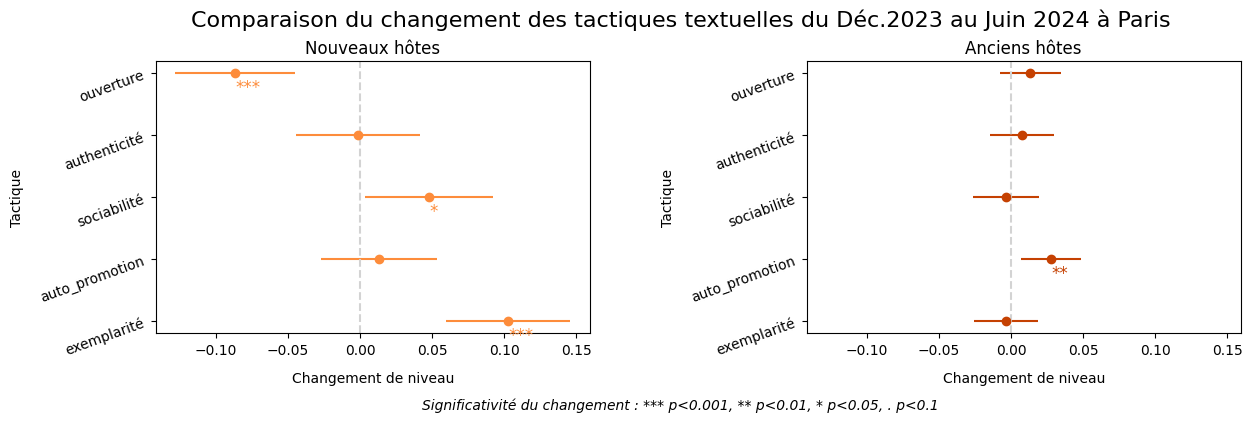

In [ ]:
# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.5, 0.8, n))


## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 4)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.5)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharex=ax1)#**
axes.extend([ax1, ax2])


#
tactics=tactics_bio
df_plot=results_ddd_new[results_ddd_new['variable'].isin(tactics)].copy()#***
subplot_col="is_new_host"

for i, new in enumerate(df_plot[subplot_col].unique()):
    print(f"{subplot_col}={new}")
    
    sub=df_plot[df_plot[subplot_col]==new].copy()
    order=tactics[::-1]
    sub = sub.set_index("variable").loc[order].reset_index()
    display(sub)

    ax=axes[i]
    ax.errorbar(
        x=sub["coef"],
        y=sub["variable"],
        # y=y,
        xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
        fmt='o', 
        color=paris_colors[i]
    )
    # ---sig---
    for _, row in sub.iterrows():
        ax.annotate(
            row["sig"],
            xy=(row["coef"], row["variable"]),
            xytext=(0, -10),         
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=12,
            color=paris_colors[i]
    )    
            
    ax.axvline(0, linestyle='--', color="lightgray", label="Changement de Londres")    
    ax.set_xlabel(f"Changement de niveau", labelpad=10)
    ax.set_ylabel('Tactique', labelpad=10)
    ax.tick_params(axis='y', rotation=20)
    ax.set_title(f"{'Nouveaux hôtes' if new==1 else 'Anciens hôtes'}")
    
    

## ---legend 2facets----
fig.suptitle(
    "Comparaison du changement des tactiques textuelles du Déc.2023 au Juin 2024 à Paris",
    fontsize=16,
    y=1.01
)

plt.figtext(
    0.5, 0.01,
    "Significativité du changement : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()



# 新房东因jo？显著增加ouv，soc，exem，旧房东则增加auto！

is_new_host=1


,variable,is_new_host,coef,se,pval,sig,ci_low,ci_high,label
0,no_person,1,-0.033293,0.014088,0.018121,*,-0.060905,-0.005680,no_person*
1,is_lifestyle,1,0.013492,0.015058,0.370259,,-0.016021,0.043005,is_lifestyle
2,is_portrait,1,0.019801,0.015543,0.202702,,-0.010664,0.050266,is_portrait


is_new_host=0


,variable,is_new_host,coef,se,pval,sig,ci_low,ci_high,label
0,no_person,0,-0.023390,0.007263,0.001281,**,-0.037626,-0.009154,no_person**
1,is_lifestyle,0,0.021157,0.007763,0.006425,**,0.005941,0.036373,is_lifestyle**
2,is_portrait,0,0.002233,0.008014,0.780503,,-0.013473,0.017939,is_portrait


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27640\2022798687.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


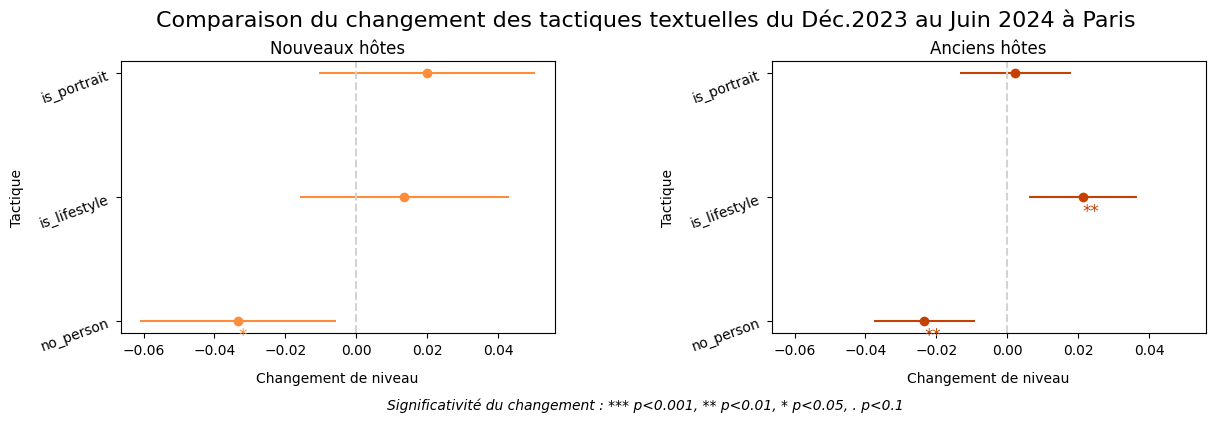

In [ ]:
# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.5, 0.8, n))


## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 4)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.5)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharex=ax1)#**
axes.extend([ax1, ax2])


#
tactics=tactics_pic_dummies

df_plot=results_ddd_new[results_ddd_new['variable'].isin(tactics)].copy()#***
subplot_col="is_new_host"

for i, new in enumerate(df_plot[subplot_col].unique()):
    print(f"{subplot_col}={new}")
    
    sub=df_plot[df_plot[subplot_col]==new].copy()
    order=tactics[::-1]
    sub = sub.set_index("variable").loc[order].reset_index()
    display(sub)

    ax=axes[i]
    ax.errorbar(
        x=sub["coef"],
        y=sub["variable"],
        # y=y,
        xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
        fmt='o', 
        color=paris_colors[i]
    )
    # ---sig---
    for _, row in sub.iterrows():
        ax.annotate(
            row["sig"],
            xy=(row["coef"], row["variable"]),
            xytext=(0, -10),         
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=12,
            color=paris_colors[i]
    )    
            
    ax.axvline(0, linestyle='--', color="lightgray", label="Changement de Londres")    
    ax.set_xlabel(f"Changement de niveau", labelpad=10)
    ax.set_ylabel('Tactique', labelpad=10)
    ax.tick_params(axis='y', rotation=20)
    ax.set_title(f"{'Nouveaux hôtes' if new==1 else 'Anciens hôtes'}")
    
    

## ---legend 2facets----
fig.suptitle(
    "Comparaison du changement des tactiques textuelles du Déc.2023 au Juin 2024 à Paris",
    fontsize=16,
    y=1.01
)

plt.figtext(
    0.5, 0.01,
    "Significativité du changement : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

# 新房东减少noperson，老房东也减少noperson，增加life??

is_new_host=1


,variable,is_new_host,coef,se,pval,sig,ci_low,ci_high,label
0,is_portrait,1,0.019801,0.015543,0.202702,,-0.010664,0.050266,is_portrait
0,is_lifestyle,1,0.013492,0.015058,0.370259,,-0.016021,0.043005,is_lifestyle
0,no_person,1,-0.033293,0.014088,0.018121,*,-0.060905,-0.005680,no_person*


is_new_host=0


,variable,is_new_host,coef,se,pval,sig,ci_low,ci_high,label
0,is_portrait,0,0.002233,0.008014,0.780503,,-0.013473,0.017939,is_portrait
0,is_lifestyle,0,0.021157,0.007763,0.006425,**,0.005941,0.036373,is_lifestyle**
0,no_person,0,-0.023390,0.007263,0.001281,**,-0.037626,-0.009154,no_person**


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27640\2104594207.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


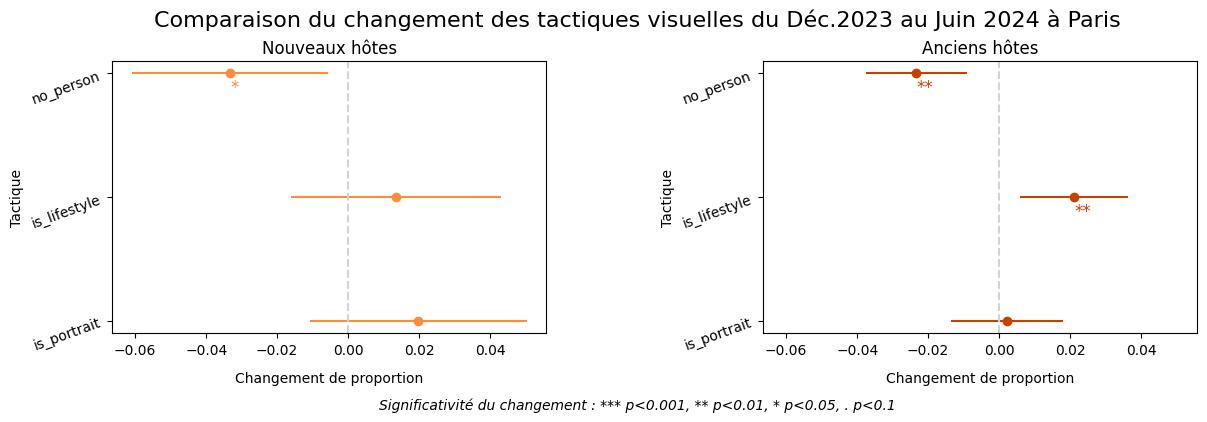

In [300]:

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.5, 0.8, n))


## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 4)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.5)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharex=ax1)#**
axes.extend([ax1, ax2])

# 
#
df_plot=results_ddd_new[results_ddd_new['variable'].isin(tactics_pic_dummies)].copy()#***
# df_plot=results_ddd[results_ddd['variable'].isin(tactics_pic_dummies)].copy()#***
subplot_col="is_new_host"
for i, new in enumerate(df_plot[subplot_col].unique()):
    print(f"{subplot_col}={new}")

    sub=df_plot[df_plot[subplot_col]==new]
    display(sub)

    ax=axes[i]
    ax.errorbar(
        x=sub["coef"],
        y=sub["variable"],
        # y=y,
        xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
        fmt='o', 
        color=paris_colors[i]
    )
    # ---sig---
    for _, row in sub.iterrows():
        ax.annotate(
            row["sig"],
            xy=(row["coef"], row["variable"]),
            xytext=(0, -10),          # 👈 向下偏移 6 points
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=12,
            color=paris_colors[i]
    )    
            
    ax.axvline(0, linestyle='--', color="lightgray", label="Changement de Londres")    
    ax.set_xlabel(f"Changement de proportion", labelpad=10)
    ax.set_ylabel('Tactique')
    ax.tick_params(axis='y', rotation=20)
    ax.set_title(f"{'Nouveaux hôtes' if new==1 else 'Anciens hôtes'}")
    
    

## ---legend 2facets----
fig.suptitle(
    "Comparaison du changement des tactiques visuelles du Déc.2023 au Juin 2024 à Paris",
    fontsize=16,
    y=1.01
)

plt.figtext(
    0.5, 0.01,
    "Significativité du changement : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

## 新房东显著减少no_person, 老房东增加life


# changment des effects des tactiques